<a href="https://colab.research.google.com/github/Prisze/AAI-590Capstone/blob/main/Capstone_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1rWs5F3UO9h1BDnFSFDhLJmDC3F0BvhSM"
output = "dataset.zip"  # change name if needed

gdown.download(url, output, quiet=False)

!unzip dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1rWs5F3UO9h1BDnFSFDhLJmDC3F0BvhSM
From (redirected): https://drive.google.com/uc?id=1rWs5F3UO9h1BDnFSFDhLJmDC3F0BvhSM&confirm=t&uuid=1b77a990-816c-49bb-97a6-a4cd831cf24a
To: /content/dataset.zip
100%|██████████| 1.81G/1.81G [00:29<00:00, 62.1MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [ ]:
import torch
from torch import nn


class CNNBlock(nn.Module):
    """
    Simple ResNet-style basic block:
    Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN + skip connection -> ReLU
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.downsample = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class SimpleCNN(nn.Module):
    """
    Small ResNet-like CNN for 256x256 images, binary classification (Real/Fake).

    Stages:
        stem:    3x3 conv -> BN -> ReLU
        stage1:  BasicBlock x2,  base_channels     -> 2*base_channels
        stage2:  BasicBlock x2,  2*base_channels   -> 4*base_channels
        stage3:  BasicBlock x2,  4*base_channels   -> 8*base_channels
        head:    global avg pool -> Dropout -> Linear -> num_classes
    """
    def __init__(
        self,
        in_channels: int = 3,
        num_classes: int = 2,
        base_channels: int = 32,
        num_blocks_per_stage: tuple[int, int, int] = (2, 2, 2),
        dropout: float = 0.3,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                base_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
        )

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8

        self.stage1 = self._make_stage(
            in_channels=c1,
            out_channels=c2,
            num_blocks=num_blocks_per_stage[0],
            stride_first=2,  # 256 -> 128
        )
        self.stage2 = self._make_stage(
            in_channels=c2,
            out_channels=c3,
            num_blocks=num_blocks_per_stage[1],
            stride_first=2,  # 128 -> 64
        )
        self.stage3 = self._make_stage(
            in_channels=c3,
            out_channels=c4,
            num_blocks=num_blocks_per_stage[2],
            stride_first=2,  # 64 -> 32
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()
        self.fc = nn.Linear(c4, num_classes)

    def _make_stage(
        self,
        in_channels: int,
        out_channels: int,
        num_blocks: int,
        stride_first: int,
    ) -> nn.Sequential:
        blocks = []
        # First block can downsample
        blocks.append(CNNBlock(in_channels, out_channels, stride=stride_first))
        # Remaining blocks keep same channels & resolution
        for _ in range(num_blocks - 1):
            blocks.append(CNNBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = self.global_pool(x)      # [B, C, 1, 1]
        x = x.flatten(1)             # [B, C]
        x = self.dropout(x)
        x = self.fc(x)               # [B, num_classes]
        return x


def build_model(
    arch: str = "simple_resnet_cnn",
    in_channels: int = 3,
    num_classes: int = 2,
    base_channels: int = 32,
    num_blocks_per_stage: tuple[int, int, int] = (2, 2, 2),
    dropout: float = 0.3,
    **kwargs,
) -> nn.Module:
    """
    Wrapper to fit run_ablation's expected signature.
    `arch` is here in case you later add more model types; for now it's fixed.
    """
    if arch != "simple_resnet_cnn":
        raise ValueError(f"Unknown architecture: {arch}")

    return SimpleCNN(
        in_channels=in_channels,
        num_classes=num_classes,
        base_channels=base_channels,
        num_blocks_per_stage=num_blocks_per_stage,
        dropout=dropout,
    )

from torch.optim import AdamW

best_model_kwargs = {
    "arch": "simple_resnet_cnn",
    "in_channels": 3,
    "num_classes": 2,
    "num_blocks_per_stage": (2, 2, 2),
    "base_channels": 48,
    "dropout": 0.0,
}

best_train_kwargs = {
    "optimizer_cls": AdamW,
    "use_amp": True,
    "grad_clip_norm": 1.0,
    "batch_size": 64,
    "base_lr": 3e-4,
    "optimizer_kwargs": {
        "weight_decay": 1e-4,
        "lr": 1e-4,
    },
}

cnn_model = build_model(**best_model_kwargs)
state_dict = torch.load('cnn.pt')
cnn_model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
import torch
from torch import nn
from torchvision.models.vision_transformer import VisionTransformer


class ViTClassifier(nn.Module):
    """
    Small Vision Transformer for 256x256 images, binary classification (Real/Fake).

    Uses torchvision.models.vision_transformer.VisionTransformer under the hood.
    """

    def __init__(
        self,
        image_size: int = 256,
        patch_size: int = 16,
        num_layers: int = 6,
        hidden_dim: int = 256,
        mlp_ratio: float = 4.0,
        dropout: float = 0.1,
        attention_dropout: float = 0.1,
        num_classes: int = 2,
    ):
        super().__init__()

        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size

        # standard ViT practice: num_heads such that hidden_dim / num_heads ~ 64
        num_heads = max(1, hidden_dim // 64)
        mlp_dim = int(hidden_dim * mlp_ratio)

        self.vit = VisionTransformer(
            image_size=image_size,
            patch_size=patch_size,
            num_layers=num_layers,
            num_heads=num_heads,
            hidden_dim=hidden_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            attention_dropout=attention_dropout,
            num_classes=num_classes,
            representation_size=None,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.vit(x)

import torch
import torch.nn as nn
from torch.optim import AdamW

def build_vit_model(
    arch: str = "small_vit",
    image_size: int = 256,
    patch_size: int = 16,
    num_layers: int = 6,
    hidden_dim: int = 256,
    mlp_ratio: float = 4.0,
    dropout: float = 0.1,
    attention_dropout: float = 0.1,
    num_classes: int = 2,
    **kwargs,
) -> nn.Module:
    """
    Wrapper compatible with run_ablation.
    `arch` is kept for consistency with the CNN setup.
    """
    if arch != "small_vit":
        raise ValueError(f"Unknown architecture: {arch}")

    return ViTClassifier(
        image_size=image_size,
        patch_size=patch_size,
        num_layers=num_layers,
        hidden_dim=hidden_dim,
        mlp_ratio=mlp_ratio,
        dropout=dropout,
        attention_dropout=attention_dropout,
        num_classes=num_classes,
    )


best_vit_model_kwargs = {
    "arch": "small_vit",
    "image_size": 256,
    "patch_size": 16,
    "num_classes": 2,
    "mlp_ratio": 4.0,
    "dropout": 0.1,
    "attention_dropout": 0.1,
    "hidden_dim": 256,
    "num_layers": 6,
}

best_vit_train_kwargs = {
    "optimizer_cls": AdamW,
    "use_amp": True,
    "grad_clip_norm": 1.0,
    "batch_size": 256,
    "base_lr": 1e-4,
    "optimizer_kwargs": {
        "weight_decay": 1e-4,
        "lr": 1e-4,
    },
}

vit_model = build_vit_model(**best_vit_model_kwargs)

state_dict = torch.load('vit.pt')
vit_model.load_state_dict(state_dict)

<All keys matched successfully>

Saving real_0.jpg to real_0 (1).jpg

File: real_0 (1).jpg
CNN prediction:
  Fake: 0.20%
  Real: 99.80%
--> CNN predicted: Real (99.80%)

ViT prediction:
  Fake: 50.20%
  Real: 49.80%
--> ViT predicted: Fake (50.20%)


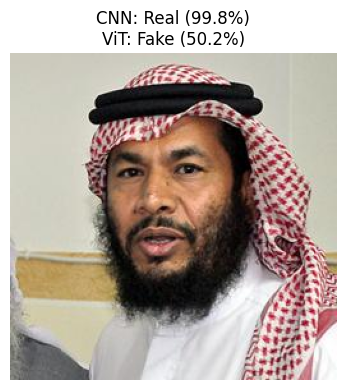

In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms

# Same class mapping as before
CLASS_NAMES = {0: "Fake", 1: "Real"}

# Device + models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device).eval()
vit_model.to(device).eval()

# Normalization used during training
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Transform for inference (resize -> tensor -> normalize)
infer_transform = transforms.Compose([
    transforms.Resize((256, 256)),   # adapt uploaded images to training size
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Upload images from your local machine
uploaded = files.upload()

for fname, file_bytes in uploaded.items():
    # Load image
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")

    # Prepare tensor for the models
    x = infer_transform(img).unsqueeze(0).to(device)  # [1, 3, 256, 256]

    with torch.no_grad():
        # CNN
        logits_cnn = cnn_model(x)                      # [1, 2]
        probs_cnn = torch.softmax(logits_cnn, dim=1)[0].cpu().numpy()

        # ViT
        logits_vit = vit_model(x)                      # [1, 2]
        probs_vit = torch.softmax(logits_vit, dim=1)[0].cpu().numpy()

    # CNN prediction
    pred_idx_cnn = int(np.argmax(probs_cnn))
    pred_class_cnn = CLASS_NAMES[pred_idx_cnn]
    pred_conf_cnn = probs_cnn[pred_idx_cnn]

    # ViT prediction
    pred_idx_vit = int(np.argmax(probs_vit))
    pred_class_vit = CLASS_NAMES[pred_idx_vit]
    pred_conf_vit = probs_vit[pred_idx_vit]

    print(f"\nFile: {fname}")

    print("CNN prediction:")
    for i, p in enumerate(probs_cnn):
        print(f"  {CLASS_NAMES[i]}: {p * 100:.2f}%")
    print(f"--> CNN predicted: {pred_class_cnn} ({pred_conf_cnn * 100:.2f}%)")

    print("\nViT prediction:")
    for i, p in enumerate(probs_vit):
        print(f"  {CLASS_NAMES[i]}: {p * 100:.2f}%")
    print(f"--> ViT predicted: {pred_class_vit} ({pred_conf_vit * 100:.2f}%)")

    # Show the original image with both predictions in the title
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"CNN: {pred_class_cnn} ({pred_conf_cnn * 100:.1f}%)\n"
        f"ViT: {pred_class_vit} ({pred_conf_vit * 100:.1f}%)"
    )
    plt.tight_layout()
    plt.show()


In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms

import ipywidgets as widgets
from IPython.display import display, clear_output

# Class mapping
CLASS_NAMES = {0: "Fake", 1: "Real"}

# Device + models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device).eval()
vit_model.to(device).eval()

# Normalization used during training
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Inference transform
infer_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Widgets
run_button = widgets.Button(
    description="Upload image & run CNN + ViT",
    icon="upload",
    layout=widgets.Layout(width="300px")
)
output_area = widgets.Output()

def run_models_on_image(img: Image.Image, fname: str):
    """Run CNN + ViT on a single PIL image and show results."""
    x = infer_transform(img).unsqueeze(0).to(device)  # [1, 3, 256, 256]

    with torch.no_grad():
        # CNN
        logits_cnn = cnn_model(x)
        probs_cnn = torch.softmax(logits_cnn, dim=1)[0].cpu().numpy()

        # ViT
        logits_vit = vit_model(x)
        probs_vit = torch.softmax(logits_vit, dim=1)[0].cpu().numpy()

    # CNN prediction
    pred_idx_cnn = int(np.argmax(probs_cnn))
    pred_class_cnn = CLASS_NAMES[pred_idx_cnn]
    pred_conf_cnn = probs_cnn[pred_idx_cnn]

    # ViT prediction
    pred_idx_vit = int(np.argmax(probs_vit))
    pred_class_vit = CLASS_NAMES[pred_idx_vit]
    pred_conf_vit = probs_vit[pred_idx_vit]

    print(f"\nFile: {fname}")

    print("CNN prediction:")
    for i, p in enumerate(probs_cnn):
        print(f"  {CLASS_NAMES[i]}: {p * 100:.2f}%")
    print(f"--> CNN predicted: {pred_class_cnn} ({pred_conf_cnn * 100:.2f}%)")

    print("\nViT prediction:")
    for i, p in enumerate(probs_vit):
        print(f"  {CLASS_NAMES[i]}: {p * 100:.2f}%")
    print(f"--> ViT predicted: {pred_class_vit} ({pred_conf_vit * 100:.2f}%)")

    # Show the image with both predictions in the title
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"CNN: {pred_class_cnn} ({pred_conf_cnn * 100:.1f}%)\n"
        f"ViT: {pred_class_vit} ({pred_conf_vit * 100:.1f}%)"
    )
    plt.tight_layout()
    plt.show()

def on_run_button_click(b):
    with output_area:
        clear_output(wait=True)
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded.")
            return

        for fname, file_bytes in uploaded.items():
            img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
            run_models_on_image(img, fname)

run_button.on_click(on_run_button_click)

display(widgets.VBox([run_button, output_area]))
